# Word2Vec + HMM NER Pipeline

This notebook trains Skip-Gram with Negative Sampling embeddings on CoNLL-2003 text, explores the learned vector space, and evaluates a simple HMM-based NER model.

## 1. Imports And Setup


In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from collections import Counter

from data.conll2003_loader import load_conll2003, load_conll2003_splits
from utils.vocabulary import build_vocab, tokenize
from models.skipgram_model import SkipGramNS
from training.skipgram_trainer import train_skipgram
from utils.embeddings_utils import word_analogy, save_embeddings, most_similar
from data.skipgram_data import create_skipgram_pairs, combine_split_sentences
from models.hmm_ner import HMM_NER
from training.neural_trainer import train_neural_model
from models.neural import FeedForwardNN, predict_tags
from sklearn.metrics import classification_report, accuracy_score
import numpy as np
import matplotlib.pyplot as plt

plt.style.use("seaborn-v0_8-whitegrid")
np.random.seed(42)

print("Environment ready.")


c:\Users\alyad\AppData\Local\Programs\Python\Python312\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment ready.


## 2. Load And Inspect The Dataset


Loading CoNLL2003 dataset...


Dataset loaded successfully.

Split sizes:
- Train: 14041
- Validation: 3250
- Test: 3453

Total sentences used for skip-gram: 20744
Average sentence length: 14.53 tokens
Median sentence length: 10 tokens

Example sentence:
['EU', 'rejects', 'German', 'call', 'to', 'boycott', 'British', 'lamb', '.']


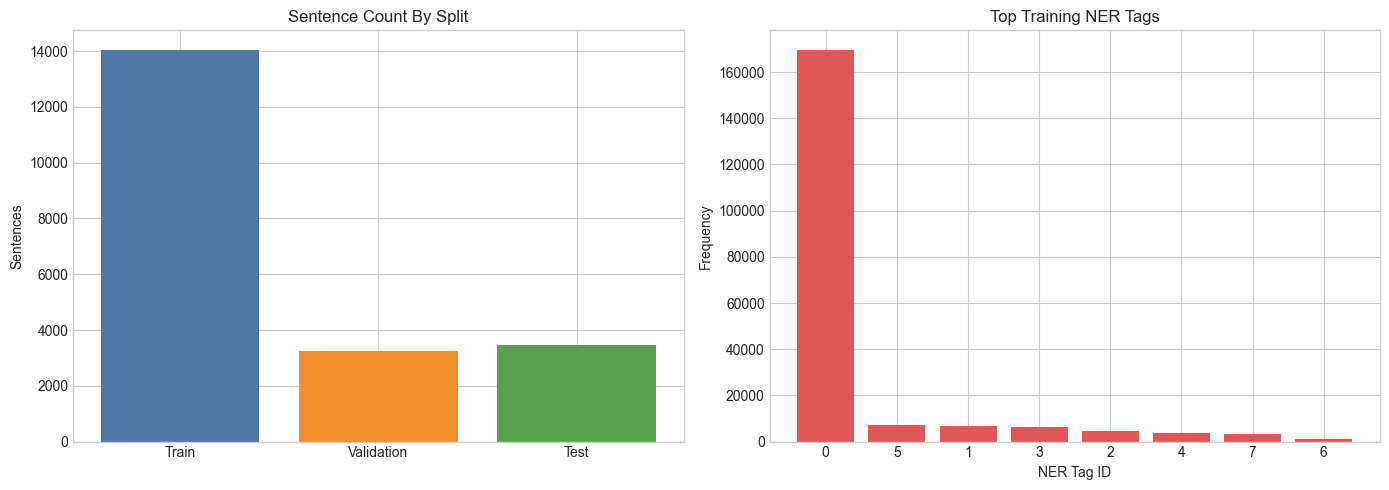

In [3]:
print("Loading CoNLL2003 dataset...")

splits, label_names, id2label, label2id = load_conll2003_splits()

(
    all_tokens,
    train_sentences,
    train_tags,
    validation_sentences,
    validation_tags,
    test_sentences,
    test_true_tags,
    _,
    _,
    _,
) = load_conll2003()


# Use all splits for skip-gram training.
sentences = combine_split_sentences(
    train_sentences, validation_sentences, test_sentences
)

split_sizes = {
    "Train": len(train_sentences),
    "Validation": len(validation_sentences),
    "Test": len(test_sentences),
}

token_lengths = [len(sentence) for sentence in sentences]
tag_counts = Counter(tag for seq in train_tags for tag in seq)
top_tags = tag_counts.most_common(8)

print("Dataset loaded successfully.\n")
print("Split sizes:")
for split_name, split_size in split_sizes.items():
    print(f"- {split_name}: {split_size}")

print(f"\nTotal sentences used for skip-gram: {len(sentences)}")
print(f"Average sentence length: {np.mean(token_lengths):.2f} tokens")
print(f"Median sentence length: {np.median(token_lengths):.0f} tokens")

print("\nExample sentence:")
print(sentences[0])

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].bar(
    split_sizes.keys(), split_sizes.values(), color=["#4e79a7", "#f28e2b", "#59a14f"]
)
axes[0].set_title("Sentence Count By Split")
axes[0].set_ylabel("Sentences")

axes[1].bar(
    [str(tag) for tag, _ in top_tags], [count for _, count in top_tags], color="#e15759"
)
axes[1].set_title("Top Training NER Tags")
axes[1].set_xlabel("NER Tag ID")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

## 3. Build The Vocabulary


In [4]:
print("Building vocabulary...")

tokenized = tokenize(sentences)
vocab, idx_to_word = build_vocab(tokenized)
V = len(vocab)

sentence_token_total = sum(len(sentence) for sentence in tokenized)
covered_token_total = sum(sum(1 for word in sentence if word in vocab) for sentence in tokenized)
coverage = covered_token_total / sentence_token_total if sentence_token_total else 0.0

print(f"Vocabulary size: {V}")
print(f"Vocabulary coverage after min_count filtering: {coverage:.2%}")

print("\nSample vocabulary items:")
for word in list(vocab.keys())[:10]:
    print(f"- {word}: {vocab[word]}")


Building vocabulary...
Vocabulary size: 15488
Vocabulary coverage after min_count filtering: 95.09%

Sample vocabulary items:
- EU: 0
- rejects: 1
- German: 2
- call: 3
- to: 4
- boycott: 5
- British: 6
- lamb: 7
- .: 8
- Peter: 9


## 4. Create Skip-Gram Training Pairs


In [5]:
print("Creating Skip-Gram dataset...")

window_size = 2
pairs = create_skipgram_pairs(tokenized, vocab, window_size)

print(f"Window size: {window_size}")
print(f"Number of training pairs: {len(pairs)}")

print("\nSample pairs:")
for target, context in pairs[:10]:
    print(f"- {idx_to_word[target]} -> {idx_to_word[context]}")


Creating Skip-Gram dataset...
Window size: 2
Number of training pairs: 1023428

Sample pairs:
- EU -> rejects
- EU -> German
- rejects -> EU
- rejects -> German
- rejects -> call
- German -> EU
- German -> rejects
- German -> call
- German -> to
- call -> rejects


## 5. Initialize The Skip-Gram Model


In [6]:
embedding_dim = 100

print("Initializing Word2Vec SGNS model...")
model = SkipGramNS(vocab_size=V, embedding_dim=embedding_dim)

print("Model initialized successfully.")
print(f"Embedding dimension: {embedding_dim}")
print(f"Input embedding matrix shape: {model.W_in.shape}")
print(f"Output embedding matrix shape: {model.W_out.shape}")


Initializing Word2Vec SGNS model...
Model initialized successfully.
Embedding dimension: 100
Input embedding matrix shape: (15488, 100)
Output embedding matrix shape: (15488, 100)


## 6. Train The Embedding Model


In [7]:
epochs = 30

loss_history = train_skipgram(
     pairs=pairs,
     vocab=vocab,
     model=model,
     neg_samples=5,
     lr=0.05,
     epochs=epochs,
)

# loss_history = train_skipgram(
#     pairs=pairs,
#     vocab=vocab,
#     model=model,
#     neg_samples=5,
#     lr=0.05,
#     epochs=epochs,
#     training_mode="mini_batch",
#     batch_size=16,
#     scale_mini_batch_lr=True,
# )

print("Training finished.")
print(f"Initial loss: {loss_history[0]:.4f}")
print(f"Final loss: {loss_history[-1]:.4f}")
print(f"Loss improvement: {loss_history[0] - loss_history[-1]:.4f}")


Epoch 01/30 | mode=sgd | lr=0.05000 | loss=1.9621
Epoch 02/30 | mode=sgd | lr=0.04833 | loss=1.3521
Epoch 03/30 | mode=sgd | lr=0.04667 | loss=1.2349
Epoch 04/30 | mode=sgd | lr=0.04500 | loss=1.1549
Epoch 05/30 | mode=sgd | lr=0.04333 | loss=1.0872
Epoch 06/30 | mode=sgd | lr=0.04167 | loss=1.0287
Epoch 07/30 | mode=sgd | lr=0.04000 | loss=0.9764
Epoch 08/30 | mode=sgd | lr=0.03833 | loss=0.9310
Epoch 09/30 | mode=sgd | lr=0.03667 | loss=0.8898
Epoch 10/30 | mode=sgd | lr=0.03500 | loss=0.8541
Epoch 11/30 | mode=sgd | lr=0.03333 | loss=0.8222
Epoch 12/30 | mode=sgd | lr=0.03167 | loss=0.7963
Epoch 13/30 | mode=sgd | lr=0.03000 | loss=0.7715
Epoch 14/30 | mode=sgd | lr=0.02833 | loss=0.7504
Epoch 15/30 | mode=sgd | lr=0.02667 | loss=0.7319
Epoch 16/30 | mode=sgd | lr=0.02500 | loss=0.7147
Epoch 17/30 | mode=sgd | lr=0.02333 | loss=0.6993
Epoch 18/30 | mode=sgd | lr=0.02167 | loss=0.6879
Epoch 19/30 | mode=sgd | lr=0.02000 | loss=0.6758
Epoch 20/30 | mode=sgd | lr=0.01833 | loss=0.6644


## 6.1 Training Visualization


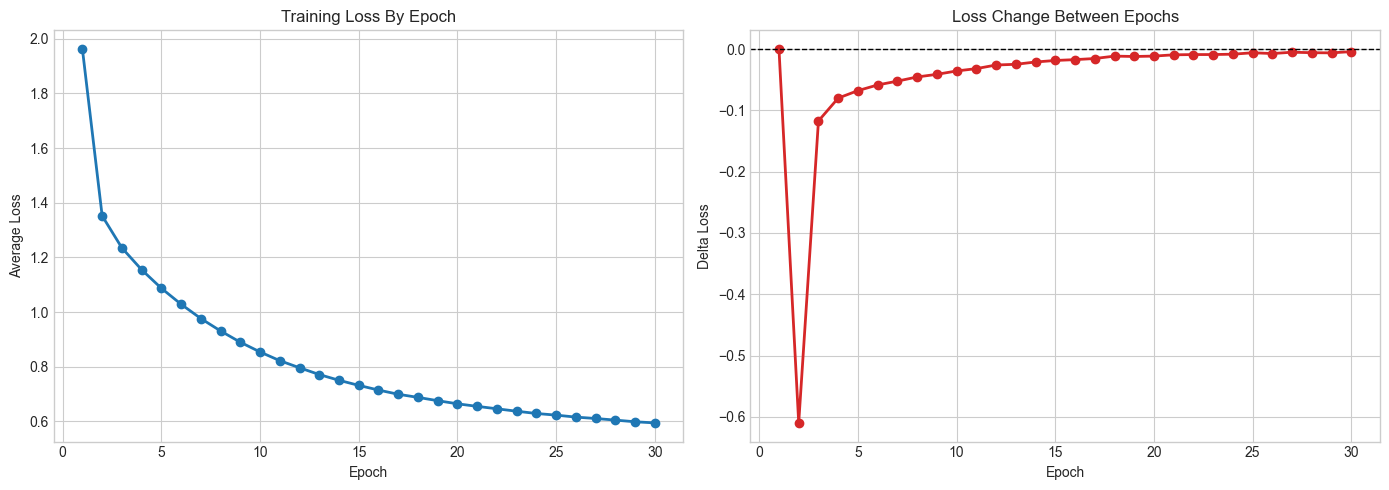

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

epochs_axis = np.arange(1, epochs + 1)
axes[0].plot(epochs_axis, loss_history, marker="o", linewidth=2, color="#1f77b4")
axes[0].set_title("Training Loss By Epoch")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Average Loss")

axes[1].plot(epochs_axis, np.diff([loss_history[0], *loss_history]), marker="o", linewidth=2, color="#d62728")
axes[1].set_title("Loss Change Between Epochs")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Delta Loss")
axes[1].axhline(0, color="black", linewidth=1, linestyle="--")

plt.tight_layout()
plt.show()


## 7. Explore Learned Embeddings


In [9]:
W_in_norm = model.W_in / (np.linalg.norm(model.W_in, axis=1, keepdims=True) + 1e-9)

test_words = [
    "year", "tournament", "match", "player",
    "team", "percent",
    "Germany", "German", "France", "French",
    "EU", "British",
]

similarity_summary = {}

for word in test_words:
    if word not in vocab:
        similarity_summary[word] = []
        continue
    similarity_summary[word] = most_similar(word, vocab, idx_to_word, W_in_norm, topk=5)

for word, results in similarity_summary.items():
    print(f"\nMost similar words to {word!r}:")
    if not results:
        print("- Word not in vocabulary")
        continue
    for rank, (neighbor, score) in enumerate(results, 1):
        print(f"{rank}. {neighbor:<15} score= {score:.4f}")



Most similar words to 'year':
1. acquitted       score= 0.5510
2. 10.5            score= 0.5421
3. accordingly     score= 0.5413
4. profitable      score= 0.5386
5. 1915.00         score= 0.5267

Most similar words to 'tournament':
1. Singer          score= 0.7115
2. trouble-free    score= 0.6994
3. four-nation     score= 0.6812
4. Hamlet          score= 0.6795
5. two-man         score= 0.6779

Most similar words to 'match':
1. one-day         score= 0.5957
2. Shield          score= 0.5884
3. cricket         score= 0.5856
4. day-night       score= 0.5651
5. basketball      score= 0.5629

Most similar words to 'player':
1. Torino          score= 0.5980
2. 36-year-old     score= 0.5888
3. Claudio         score= 0.5824
4. arguing         score= 0.5704
5. Aston           score= 0.5704

Most similar words to 'team':
1. touring         score= 0.6173
2. batted          score= 0.5396
3. CAPS            score= 0.5349
4. mate            score= 0.5056
5. s               score= 0.5043

Most simil

## 8. Save Embeddings


In [10]:
embeddings_file = "embeddings.txt"
save_embeddings(model.W_in, idx_to_word, embeddings_file)
print(f"Embeddings saved to {embeddings_file}")


Embeddings saved to embeddings.txt


## 9. Word Analogy Checks


In [11]:
analogy_tests = [
    ("Germany", "German", "France"),
    ("France", "French", "Germany"),
    ("Kohl", "Germany", "Chirac"),
    ("Clinton", "America", "Kohl"),
    ("EU", "Europe", "UN"),
    ("Paris", "France", "Rome"),
    ("president", "government", "minister"),
    ("year", "years", "month"),
    ("match", "team", "tournament"),
]

for a, b, c in analogy_tests:
    print(f"\n{a} : {b} :: {c} : ?")
    if a not in vocab or b not in vocab or c not in vocab:
        print("- Skipped because one or more words are missing from the vocabulary")
        continue
    results = word_analogy(a, b, c, W_in_norm, vocab, idx_to_word, topk=5)
    for rank, (word, score) in enumerate(results, 1):
        print(f"{rank}. {word:<15} score={score:.4f}")



Germany : German :: France : ?
1. until           score=0.4340
2. Helmut          score=0.4267
3. Duke            score=0.4151
4. Italian         score=0.4092
5. defence         score=0.3993

France : French :: Germany : ?
1. German          score=0.4828
2. bonds           score=0.3914
3. company         score=0.3644
4. attache         score=0.3568
5. organist        score=0.3566

Kohl : Germany :: Chirac : ?
1. Alina           score=0.6410
2. Falk            score=0.6348
3. Silke           score=0.6242
4. Katja           score=0.6237
5. Sven            score=0.6112

Clinton : America :: Kohl : ?
1. Relations       score=0.5862
2. Chancellor      score=0.5698
3. unification     score=0.5676
4. Helmut          score=0.5585
5. Malbak          score=0.5468

EU : Europe :: UN : ?
1. reference       score=0.5644
2. Caucasus        score=0.5607
3. command         score=0.5501
4. Allied          score=0.5299
5. recommending    score=0.5245

Paris : France :: Rome : ?


1. Sandrine        score=0.5557
2. Arnaud          score=0.5452
3. Anne-Gaelle     score=0.5331
4. Guillaume       score=0.5194
5. Regine          score=0.5164

president : government :: minister : ?
1. Moustapha       score=0.4991
2. Clarke          score=0.4876
3. ministry        score=0.4831
4. withdraw        score=0.4687
5. 13-month-old    score=0.4652

year : years :: month : ?
1. weeks           score=0.4487
2. no-confidence   score=0.4421
3. put             score=0.4174
4. Umberto         score=0.3976
5. Mobutu          score=0.3970

match : team :: tournament : ?
1. touring         score=0.5064
2. badminton       score=0.4789
3. squash          score=0.4741
4. CAPS            score=0.4568
5. x               score=0.4512


## 10. Train And Evaluate The HMM NER Model


In [12]:
hmm = HMM_NER(unk_threshold=1, k_trans=0.5, k_emit=0.1, use_bio_constraints=True)
hmm.train(train_sentences, train_tags)

predicted_tags = [hmm.viterbi(sentence) for sentence in test_sentences]

flat_true = [tag for seq in test_true_tags for tag in seq]
flat_pred = [tag for seq in predicted_tags for tag in seq]


accuracy = accuracy_score(flat_true, flat_pred)
print(f"Accuracy: {accuracy:.4f}\n")
print(classification_report(flat_true, flat_pred, zero_division=0))

example_idx = 14
print("Tokens:      ", test_sentences[example_idx])
print("True tags:   ", [id2label.get(t, str(t)) for t in test_true_tags[example_idx]])
print("Predicted:   ", [id2label.get(t, str(t)) for t in predicted_tags[example_idx]])

Accuracy: 0.9423

              precision    recall  f1-score   support

           0       0.98      0.98      0.98     38323
           1       0.84      0.72      0.78      1617
           2       0.82      0.97      0.89      1156
           3       0.67      0.69      0.68      1661
           4       0.69      0.73      0.71       835
           5       0.89      0.77      0.83      1668
           6       0.72      0.61      0.66       257
           7       0.80      0.69      0.74       702
           8       0.58      0.69      0.63       216

    accuracy                           0.94     46435
   macro avg       0.78      0.76      0.77     46435
weighted avg       0.94      0.94      0.94     46435

Tokens:       ['Japan', 'then', 'laid', 'siege', 'to', 'the', 'Syrian', 'penalty', 'area', 'for', 'most', 'of', 'the', 'game', 'but', 'rarely', 'breached', 'the', 'Syrian', 'defence', '.']
True tags:    ['B-LOC', 'O', 'O', 'O', 'O', 'O', 'B-MISC', 'O', 'O', 'O', 'O', 'O', 'O',

## 11. Train And Tune Neural Network Model

In [13]:
best_params, best_weights = train_neural_model(
    train_sentences,
    train_tags,
    validation_sentences,
    validation_tags,
    model.W_in,
    vocab,
    label_names,
    epochs=20,
)

best_model = FeedForwardNN(
    embedding_dim=model.W_in.shape[1],
    window_size=best_params["window_size"],
    hidden_dim=best_params["hidden_dim"],
    num_classes=len(label_names),
)

Tuning hyperparameters...
Testing combination: {'hidden_dim': 32, 'learning_rate': 0.001, 'window_size': 3, 'dropout_rate': 0.1, 'weight_decay': 0.0001}


c:\Users\alyad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/20, Loss: 0.3602
Epoch 2/20, Loss: 0.2681
Epoch 3/20, Loss: 0.2446
Epoch 4/20, Loss: 0.2327
Epoch 5/20, Loss: 0.2255
Epoch 6/20, Loss: 0.2194
Epoch 7/20, Loss: 0.2160
Epoch 8/20, Loss: 0.2125
Epoch 9/20, Loss: 0.2097
Epoch 10/20, Loss: 0.2068
Epoch 11/20, Loss: 0.2057
Epoch 12/20, Loss: 0.2035
Epoch 13/20, Loss: 0.2025
Epoch 14/20, Loss: 0.2013
Epoch 15/20, Loss: 0.2018
Epoch 16/20, Loss: 0.1996
Epoch 17/20, Loss: 0.1999
Epoch 18/20, Loss: 0.1994
Epoch 19/20, Loss: 0.1987
Epoch 20/20, Loss: 0.1968
Evaluating on Validation Set...
Accuracy: 0.9454 | Precision: 0.8659 | Recall: 0.7086 | F1: 0.7716
*** New Best F1-Score: 0.7716! ***
Testing combination: {'hidden_dim': 32, 'learning_rate': 0.001, 'window_size': 3, 'dropout_rate': 0.1, 'weight_decay': 1e-05}


c:\Users\alyad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/20, Loss: 0.3513
Epoch 2/20, Loss: 0.2631
Epoch 3/20, Loss: 0.2426
Epoch 4/20, Loss: 0.2308
Epoch 5/20, Loss: 0.2228
Epoch 6/20, Loss: 0.2172
Epoch 7/20, Loss: 0.2123
Epoch 8/20, Loss: 0.2095
Epoch 9/20, Loss: 0.2072
Epoch 10/20, Loss: 0.2041
Epoch 11/20, Loss: 0.2031
Epoch 12/20, Loss: 0.2005
Epoch 13/20, Loss: 0.1992
Epoch 14/20, Loss: 0.1975
Epoch 15/20, Loss: 0.1963
Epoch 16/20, Loss: 0.1955
Epoch 17/20, Loss: 0.1952
Epoch 18/20, Loss: 0.1940
Epoch 19/20, Loss: 0.1922
Epoch 20/20, Loss: 0.1923
Evaluating on Validation Set...
Accuracy: 0.9458 | Precision: 0.8442 | Recall: 0.7216 | F1: 0.7742
*** New Best F1-Score: 0.7742! ***
Testing combination: {'hidden_dim': 32, 'learning_rate': 0.001, 'window_size': 3, 'dropout_rate': 0.3, 'weight_decay': 0.0001}


...

Epoch 1/20, Loss: 0.3366
Epoch 2/20, Loss: 0.2332
Epoch 3/20, Loss: 0.2055
Epoch 4/20, Loss: 0.1872
Epoch 5/20, Loss: 0.1745
Epoch 6/20, Loss: 0.1649
Epoch 7/20, Loss: 0.1566
Epoch 8/20, Loss: 0.1502
Epoch 9/20, Loss: 0.1434
Epoch 10/20, Loss: 0.1391
Epoch 11/20, Loss: 0.1338
Epoch 12/20, Loss: 0.1305
Epoch 13/20, Loss: 0.1270
Epoch 14/20, Loss: 0.1236
Epoch 15/20, Loss: 0.1198
Epoch 16/20, Loss: 0.1172
Epoch 17/20, Loss: 0.1148
Epoch 18/20, Loss: 0.1127
Epoch 19/20, Loss: 0.1112
Epoch 20/20, Loss: 0.1084
Evaluating on Validation Set...
Accuracy: 0.9546 | Precision: 0.8831 | Recall: 0.7561 | F1: 0.8101
Testing combination: {'hidden_dim': 128, 'learning_rate': 0.0005, 'window_size': 5, 'dropout_rate': 0.5, 'weight_decay': 0.0001}


c:\Users\alyad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/20, Loss: 0.3622
Epoch 2/20, Loss: 0.2601
Epoch 3/20, Loss: 0.2350
Epoch 4/20, Loss: 0.2211
Epoch 5/20, Loss: 0.2107
Epoch 6/20, Loss: 0.2027
Epoch 7/20, Loss: 0.1971
Epoch 8/20, Loss: 0.1924
Epoch 9/20, Loss: 0.1891
Epoch 10/20, Loss: 0.1839
Epoch 11/20, Loss: 0.1817
Epoch 12/20, Loss: 0.1785
Epoch 13/20, Loss: 0.1769
Epoch 14/20, Loss: 0.1745
Epoch 15/20, Loss: 0.1748
Epoch 16/20, Loss: 0.1710
Epoch 17/20, Loss: 0.1696
Epoch 18/20, Loss: 0.1693
Epoch 19/20, Loss: 0.1667
Epoch 20/20, Loss: 0.1652
Evaluating on Validation Set...
Accuracy: 0.9526 | Precision: 0.8934 | Recall: 0.7265 | F1: 0.7911
Testing combination: {'hidden_dim': 128, 'learning_rate': 0.0005, 'window_size': 5, 'dropout_rate': 0.5, 'weight_decay': 1e-05}


c:\Users\alyad\AppData\Local\Programs\Python\Python312\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


Epoch 1/20, Loss: 0.3611
Epoch 2/20, Loss: 0.2589
Epoch 3/20, Loss: 0.2336
Epoch 4/20, Loss: 0.2180
Epoch 5/20, Loss: 0.2069
Epoch 6/20, Loss: 0.2000
Epoch 7/20, Loss: 0.1929
Epoch 8/20, Loss: 0.1867
Epoch 9/20, Loss: 0.1826
Epoch 10/20, Loss: 0.1785
Epoch 11/20, Loss: 0.1754
Epoch 12/20, Loss: 0.1709
Epoch 13/20, Loss: 0.1688
Epoch 14/20, Loss: 0.1664
Epoch 15/20, Loss: 0.1639
Epoch 16/20, Loss: 0.1626
Epoch 17/20, Loss: 0.1593
Epoch 18/20, Loss: 0.1567
Epoch 19/20, Loss: 0.1554
Epoch 20/20, Loss: 0.1550
Evaluating on Validation Set...
Accuracy: 0.9529 | Precision: 0.8766 | Recall: 0.7433 | F1: 0.7997
TUNING COMPLETE
Best Parameters: {'hidden_dim': 128, 'learning_rate': 0.0005, 'window_size': 3, 'dropout_rate': 0.1, 'weight_decay': 0.0001}
Best Validation F1: 0.8194


## 12. Evaluate and Test Neural Network model

In [14]:
best_model.load_state_dict(best_weights)
best_model.eval()

neural_predicted_tags = [
    predict_tags(
        sentence=sentence,
        model=best_model,
        embeddings=model.W_in,
        word2idx=vocab,
        label_names=label_names,
        window_size=best_params["window_size"],
        unk_vector= np.mean(model.W_in, axis=0),
    )
    for sentence in test_sentences
]

flat_true = [label_names[tag] for seq in test_true_tags for tag in seq]
flat_pred = [tag for seq in neural_predicted_tags for tag in seq]

accuracy = accuracy_score(flat_true, flat_pred)
print(f"Neural accuracy: {accuracy:.4f}\n")
print(classification_report(flat_true, flat_pred, zero_division=0))

example_idx = 14
print("Tokens:      ", test_sentences[example_idx])
print("True tags:   ", [label_names[tag] for tag in test_true_tags[example_idx]])
print("Predicted:   ", neural_predicted_tags[example_idx])

Neural accuracy: 0.9411

              precision    recall  f1-score   support

       B-LOC       0.85      0.80      0.82      1668
      B-MISC       0.72      0.64      0.68       702
       B-ORG       0.80      0.69      0.74      1661
       B-PER       0.86      0.79      0.82      1617
       I-LOC       0.80      0.64      0.71       257
      I-MISC       0.54      0.60      0.56       216
       I-ORG       0.77      0.71      0.74       835
       I-PER       0.86      0.79      0.82      1156
           O       0.97      0.98      0.97     38323

    accuracy                           0.94     46435
   macro avg       0.80      0.74      0.76     46435
weighted avg       0.94      0.94      0.94     46435

Tokens:       ['Japan', 'then', 'laid', 'siege', 'to', 'the', 'Syrian', 'penalty', 'area', 'for', 'most', 'of', 'the', 'game', 'but', 'rarely', 'breached', 'the', 'Syrian', 'defence', '.']
True tags:    ['B-LOC', 'O', 'O', 'O', 'O', 'O', 'B-MISC', 'O', 'O', 'O', 'O', 'O